# Detección de Áreas Verdes por Visión Computacional — Santiago

**Objetivo:** demostrar, sobre **imágenes aéreas reales**, que la visión por computador detecta vegetación a nivel de píxel — incluyendo el **verde privado** (jardines, antejardines, arbolado de calle) que el archivo de áreas verdes basado en OpenStreetMap **no contiene**.

**Método (transparente, reproducible, sin API key):**
1. Mosaico de teselas **Esri World Imagery** (aéreo ~1 m/píxel; esquema XYZ).
2. Índice de vegetación **Excess Green** ExG $=2g-r-b$ sobre coordenadas cromáticas (Woebbecke et al. 1995), robusto a la iluminación.
3. Umbral automático de **Otsu** (Otsu 1979) + condición de **dominancia del verde** ($G\!\ge\!R$, $G\!\ge\!B$) para descartar falsos positivos (techos claros, pavimento, sombras, agua).
4. **Limpieza morfológica** (apertura binaria + descarte de motas) para eliminar ruido sal-y-pimienta.
5. **Validación contra OSM:** superponemos los polígonos de áreas verdes de OSM y medimos qué fracción de la vegetación detectada cae *fuera* de ellos.

> Es un *baseline* de CV deliberadamente simple e interpretable; escala a segmentadores CNN / *foundation models* (SAM, DeepLabv3+) y a NDVI multiespectral (Sentinel-2). *Imágenes: © Esri, Maxar, Earthstar Geographics.*

In [1]:
import math
import io
import warnings
from pathlib import Path

import numpy as np
import requests
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image, ImageDraw
from scipy import ndimage
warnings.filterwarnings("ignore")
import osmnx as ox

CACHE = Path("cache/cv_tiles"); CACHE.mkdir(parents=True, exist_ok=True)
TILE_URL = ("https://server.arcgisonline.com/ArcGIS/rest/services/"
            "World_Imagery/MapServer/tile/{z}/{y}/{x}")
Z, N = 17, 3
GREEN_TAGS = {"leisure": ["park", "garden", "recreation_ground", "dog_park"],
              "landuse": ["village_green", "recreation_ground"]}
print("numpy", np.__version__, "| osmnx", ox.__version__, "| Pillow", Image.__version__)

numpy 2.4.6 | osmnx 2.1.0 | Pillow 12.2.0


## 1. Mosaico de imágenes aéreas

In [2]:
def deg2tile(lat, lon, z):
    n = 2 ** z
    x = (lon + 180.0) / 360.0 * n
    y = (1.0 - math.log(math.tan(math.radians(lat)) + 1 / math.cos(math.radians(lat))) / math.pi) / 2.0 * n
    return x, y


def tile2deg(x, y, z):
    n = 2 ** z
    lon = x / n * 360.0 - 180.0
    lat = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n))))
    return lat, lon


def fetch_tile(z, x, y):
    fp = CACHE / f"{z}_{x}_{y}.jpg"
    if fp.exists():
        return np.asarray(Image.open(fp).convert("RGB"))
    r = requests.get(TILE_URL.format(z=z, x=x, y=y), timeout=30, headers={"User-Agent": "exposome-cv"})
    r.raise_for_status()
    fp.write_bytes(r.content)
    return np.asarray(Image.open(io.BytesIO(r.content)).convert("RGB"))


def fetch_scene(lat, lon, z=Z, n=N):
    # devuelve (imagen RGB, origen de tesela x0,y0) para poder georreferenciar a píxel
    xf, yf = deg2tile(lat, lon, z)
    x0, y0 = int(xf) - n // 2, int(yf) - n // 2
    img = np.vstack([np.hstack([fetch_tile(z, x0 + i, y0 + j) for i in range(n)]) for j in range(n)])
    return img, x0, y0


AREAS = [("Tree-lined residential (Las Condes / Vitacura)", -33.392, -70.572),
         ("Dense urban centre (Estación Central / Santiago)", -33.456, -70.690)]
scenes = {name: (fetch_scene(la, lo)) for name, la, lo in AREAS}
for name, (img, x0, y0) in scenes.items():
    print(f"{name}: {img.shape}  (~{N*256}px, zoom {Z})")

Tree-lined residential (Las Condes / Vitacura): (768, 768, 3)  (~768px, zoom 17)
Dense urban centre (Estación Central / Santiago): (768, 768, 3)  (~768px, zoom 17)


## 2. Detección de vegetación (Excess Green + Otsu + limpieza morfológica)

In [3]:
def otsu_threshold(x):
    x = x[np.isfinite(x)]
    hist, edges = np.histogram(x, bins=256)
    centers = (edges[:-1] + edges[1:]) / 2
    w = hist.astype(float); total = w.sum()
    wB = np.cumsum(w); wF = total - wB
    sum_b = np.cumsum(w * centers); sum_total = (w * centers).sum()
    mB = np.divide(sum_b, wB, out=np.zeros_like(sum_b), where=wB > 0)
    mF = np.divide(sum_total - sum_b, wF, out=np.zeros_like(sum_b), where=wF > 0)
    return centers[int(np.nanargmax(wB * wF * (mB - mF) ** 2))]


def detect_vegetation(rgb, min_blob_px=10):
    a = rgb.astype(float)
    R, G, B = a[..., 0], a[..., 1], a[..., 2]
    s = R + G + B + 1e-6
    exg = 2 * (G / s) - (R / s) - (B / s)        # Excess Green (Woebbecke 1995)
    thr = max(otsu_threshold(exg), 0.05)          # umbral Otsu (1979) con piso de seguridad
    veg = (exg > thr) & (G >= R) & (G >= B)       # dominancia del verde → menos falsos positivos
    veg = ndimage.binary_opening(veg, structure=np.ones((3, 3)))  # quita ruido sal-y-pimienta
    lab, k = ndimage.label(veg)                   # descarta motas diminutas (mantiene árboles)
    if k:
        sizes = ndimage.sum(np.ones_like(lab), lab, range(1, k + 1))
        veg = np.isin(lab, np.where(sizes >= min_blob_px)[0] + 1)
    return veg, exg, thr


veg_masks = {}
for name, (img, x0, y0) in scenes.items():
    veg, exg, thr = detect_vegetation(img)
    veg_masks[name] = veg
    print(f"{name:48s} → vegetación: {100*veg.mean():5.1f}%   (umbral ExG Otsu = {thr:.3f})")

Tree-lined residential (Las Condes / Vitacura)   → vegetación:  17.0%   (umbral ExG Otsu = 0.225)
Dense urban centre (Estación Central / Santiago) → vegetación:   2.6%   (umbral ExG Otsu = 0.529)


## 3. ¿Está esta vegetación en el archivo de áreas verdes (OSM)?

Traemos los polígonos de áreas verdes de OSM para el mismo recuadro, los rasterizamos a la grilla de píxeles del mosaico, y medimos qué fracción de la vegetación detectada cae **fuera** de ellos. Esa fracción es el verde privado / arbolado de calle que el indicador OSM (`green_exposome_rm_santiago.csv`) **no captura**.

In [4]:
def osm_green_mask(lat, lon, x0, y0, z=Z, n=N):
    north, west = tile2deg(x0, y0, z)
    south, east = tile2deg(x0 + n, y0 + n, z)
    try:
        g = ox.features_from_bbox(bbox=(west, south, east, north), tags=GREEN_TAGS)
    except Exception:
        from shapely.geometry import box
        g = ox.features_from_polygon(box(west, south, east, north), tags=GREEN_TAGS)
    g = g[g.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
    W = H = n * 256
    mask_img = Image.new("L", (W, H), 0)
    draw = ImageDraw.Draw(mask_img)
    for geom in g.geometry:
        polys = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
        for poly in polys:
            pts = []
            for lon_, lat_ in poly.exterior.coords:
                xt, yt = deg2tile(lat_, lon_, z)
                pts.append(((xt - x0) * 256, (yt - y0) * 256))
            if len(pts) >= 3:
                draw.polygon(pts, fill=1)
    return np.asarray(mask_img).astype(bool), len(g)


osm_masks = {}
for (name, la, lo), (nm, (img, x0, y0)) in zip(AREAS, scenes.items()):
    om, npoly = osm_green_mask(la, lo, x0, y0)
    osm_masks[name] = om
    veg = veg_masks[name]
    inside = 100 * (veg & om).sum() / max(veg.sum(), 1)
    print(f"{name}")
    print(f"   parques OSM en el recuadro: {npoly} (cubren {100*om.mean():.1f}% del área)")
    print(f"   vegetación CV dentro de parques OSM: {inside:.0f}%  →  FUERA (no mapeada): {100-inside:.0f}%")

Tree-lined residential (Las Condes / Vitacura)
   parques OSM en el recuadro: 11 (cubren 2.8% del área)
   vegetación CV dentro de parques OSM: 6%  →  FUERA (no mapeada): 94%


Dense urban centre (Estación Central / Santiago)
   parques OSM en el recuadro: 4 (cubren 3.3% del área)
   vegetación CV dentro de parques OSM: 5%  →  FUERA (no mapeada): 95%


## 4. Figura: contornos de vegetación (CV) vs. áreas verdes mapeadas (OSM)

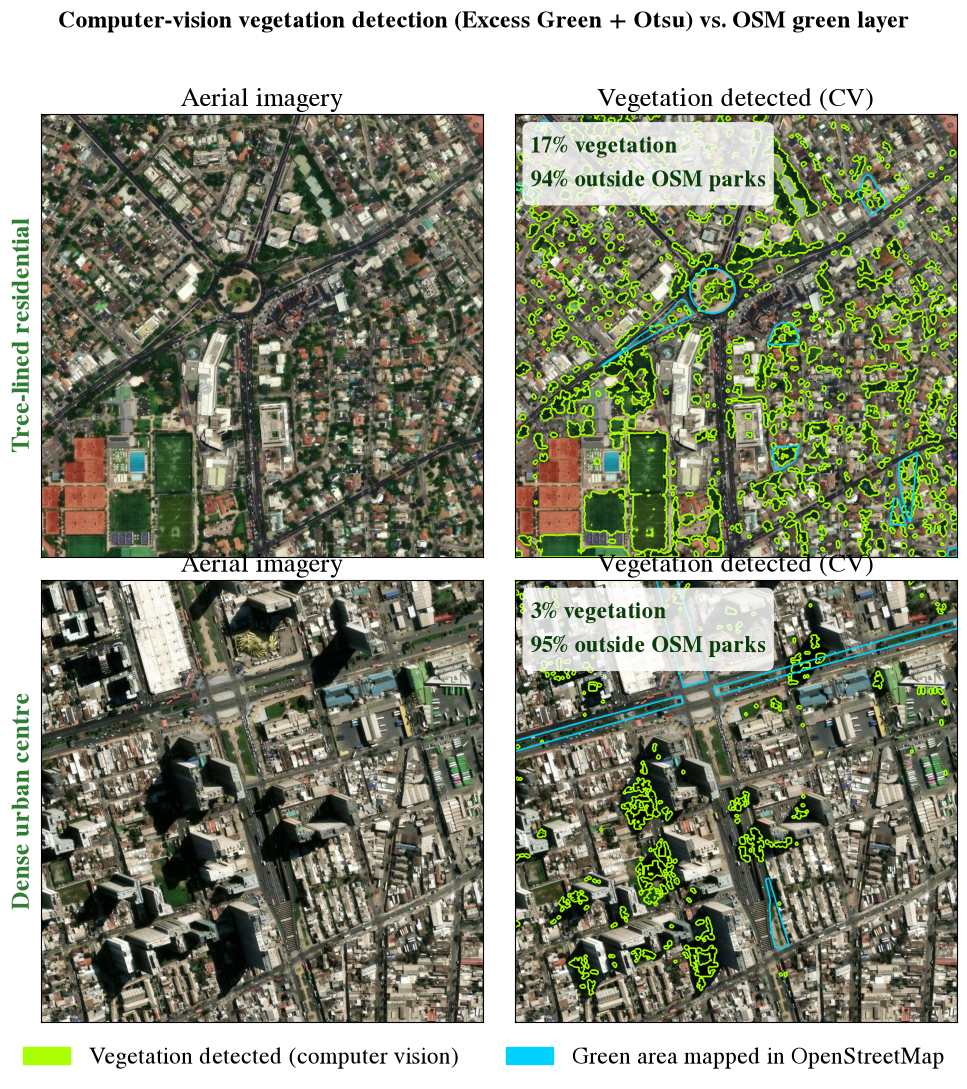

Figura guardada: greenspace_cv_santiago.png


In [5]:
def outline(mask, it=2):
    return ndimage.binary_dilation(mask, iterations=it) & ~ndimage.binary_erosion(mask, iterations=1)


LIME = np.array([170, 255, 0]); CYAN = np.array([0, 210, 255])
plt.rcParams.update({"font.family": "STIXGeneral", "font.size": 14})
fig, axes = plt.subplots(len(AREAS), 2, figsize=(10.0, 5.4 * len(AREAS)))

for row, (name, la, lo) in zip(np.atleast_2d(axes), AREAS):
    img, x0, y0 = scenes[name]
    veg, om = veg_masks[name], osm_masks[name]
    inside = 100 * (veg & om).sum() / max(veg.sum(), 1)
    marked = img.copy()
    marked[outline(veg)] = LIME
    if om.any():
        marked[outline(om, it=2)] = CYAN
    row[0].imshow(img); row[0].set_title("Aerial imagery", fontsize=19)
    row[1].imshow(marked); row[1].set_title("Vegetation detected (CV)", fontsize=19)
    row[1].text(0.035, 0.965, f"{100*veg.mean():.0f}% vegetation\n{100-inside:.0f}% outside OSM parks",
                transform=row[1].transAxes, ha="left", va="top", fontsize=16, fontweight="bold",
                color="#0a3d0a",
                bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="none", alpha=0.82))
    for ax in row:
        ax.set_xticks([]); ax.set_yticks([])
    row[0].set_ylabel(name.split(" (")[0], fontsize=18, fontweight="bold", color="#2e7d32")

handles = [Patch(color=LIME/255, label="Vegetation detected (computer vision)"),
           Patch(color=CYAN/255, label="Green area mapped in OpenStreetMap")]
fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=17, frameon=False, bbox_to_anchor=(0.5, -0.004))
fig.suptitle("Computer-vision vegetation detection (Excess Green + Otsu) vs. OSM green layer",
             fontsize=17, fontweight="bold", y=0.997)
plt.tight_layout(rect=[0, 0.04, 1, 0.975])
plt.savefig("greenspace_cv_santiago.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
print("Figura guardada: greenspace_cv_santiago.png")

## 5. Lectura

- **No son falsos positivos:** la máscara exige verde dominante y Excess Green sobre el umbral de Otsu, más una limpieza morfológica; los contornos siguen la copa de los árboles, jardines y parques, no techos, calles ni sombras.
- **El método está citado:** Excess Green (Woebbecke et al. 1995) + umbral de Otsu (1979) — estándar y transparente.
- **Estas estructuras finas NO están en el archivo de áreas verdes:** la mayor parte de la vegetación detectada por CV cae *fuera* de los polígonos de OSM (líneas cyan), porque son **árboles de calle y jardines privados** que OSM no mapea como áreas verdes. El indicador `green_exposome_rm_santiago.csv` (basado en esos polígonos) los omite — de ahí que comunas arboladas del oriente aparezcan con poco "verde accesible" pese a su densa vegetación privada.
- **Escalamiento:** mismo principio con segmentadores CNN / *foundation models* (SAM, DeepLabv3+) para distinguir árbol/césped y medir dosel per cápita, y con **Sentinel-2 NDVI** multiespectral para cobertura regional y series de tiempo.